# Module 05 — The Transformer Block (notebook)

Walkthrough of [`block.py`](block.py) and [`rope.py`](rope.py). We'll:

1. Verify RMSNorm is essentially LayerNorm with the mean dropped (and faster).
2. Build a SwiGLU FFN and confirm the 8/3 param-equivalence with a vanilla 4× MLP.
3. Numerically verify RoPE's relative-position property — the whole reason it works.
4. Visualize PI / NTK / YaRN frequency curves for long-context extension.
5. Compose a `TransformerBlock` on top of MHA, GQA, and MLA from Module 04.

**Compute:** CPU is enough for everything.  
**Time:** ~15 minutes.

In [1]:
import math
import sys, pathlib

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Module 05 components first so its rope.py (canonical, with YaRN) wins
# over Module 04's minimal rope.py when both are on sys.path.
from block import RMSNorm, SwiGLU, TransformerBlock, swiglu_hidden_dim
from rope import (
    precompute_freqs_cis, apply_rotary_emb,
    precompute_freqs_cis_pi, precompute_freqs_cis_ntk, precompute_freqs_cis_yarn,
)

# Then Module 04's attention — appended so Module 05's rope still resolves first.
sys.path.append(str(pathlib.Path.cwd().parent / "04-attention"))
from attention import MultiHeadAttention, GroupedQueryAttention, MultiHeadLatentAttention

torch.manual_seed(0)
print("torch:", torch.__version__)

torch: 2.12.0+cu130


## 1. RMSNorm vs LayerNorm — equivalence and speedup

The claim from the README: RMSNorm matches LayerNorm in quality but skips one reduction (the mean) and is faster. Let's check both halves.

In [2]:
B, T, D = 2, 64, 512
x = torch.randn(B, T, D) * 3.0

# Plain LayerNorm and our RMSNorm.
ln = nn.LayerNorm(D, eps=1e-6)
rms = RMSNorm(D, eps=1e-6)

y_ln = ln(x)
y_rms = rms(x)

# If the input already has zero mean per token, LayerNorm and RMSNorm should
# be very close. Force it and compare.
x_centered = x - x.mean(-1, keepdim=True)
y_ln_c = ln(x_centered)
y_rms_c = rms(x_centered)
max_diff = (y_ln_c - y_rms_c).abs().max().item()
print(f"max |LN - RMS| on zero-mean input: {max_diff:.2e}  (should be ~1e-6)")

# With a non-zero mean, RMSNorm and LayerNorm differ — that's the whole
# distinction. The mean RMSNorm DOESN'T subtract is what makes it cheaper.
print(f"max |LN - RMS| on raw input:       {(y_ln - y_rms).abs().max().item():.2e}")
print(f"input mean per token (sample):     {x[0, 0].mean().item():.4f}")

max |LN - RMS| on zero-mean input: 4.77e-07  (should be ~1e-6)
max |LN - RMS| on raw input:       1.51e-01
input mean per token (sample):     0.1874


In [3]:
# Microbenchmark: how much faster is RMSNorm than LayerNorm?
#
# Important: our `RMSNorm` class is composed of half a dozen elementwise
# PyTorch ops; each one is a separate kernel launch with intermediate
# allocations. PyTorch's `nn.LayerNorm` is a single fused kernel. So a
# naive bench of `RMSNorm` vs `nn.LayerNorm` would show RMSNorm LOSING.
#
# What matters at training scale is the fused-vs-fused comparison.
# PyTorch 2.4+ ships `F.rms_norm` (and `nn.RMSNorm`) as fused kernels.
# Llama / Megatron / vLLM all use fused RMSNorm in production. Our
# Python class is for the readable-implementation half of the module;
# the bench below uses the fused kernel for the speed claim.
import time

x_big = torch.randn(8, 512, 2048)  # B=8, T=512, D=2048

ln = nn.LayerNorm(2048)
rms_fused = nn.RMSNorm(2048)  # PyTorch's fused implementation

for _ in range(3):
    _ = ln(x_big); _ = rms_fused(x_big)

N = 30
t0 = time.perf_counter()
for _ in range(N):
    _ = ln(x_big)
ln_ms = (time.perf_counter() - t0) * 1000 / N

t0 = time.perf_counter()
for _ in range(N):
    _ = rms_fused(x_big)
rms_ms = (time.perf_counter() - t0) * 1000 / N

print(f"nn.LayerNorm  (fused): {ln_ms:.2f} ms/call")
print(f"nn.RMSNorm    (fused): {rms_ms:.2f} ms/call")
print(f"speedup:               {ln_ms / rms_ms:.2f}x")

nn.LayerNorm  (fused): 11.16 ms/call
nn.RMSNorm    (fused): 30.55 ms/call
speedup:               0.37x


On CPU you might see RMSNorm come out *slower* than LayerNorm — PyTorch's LayerNorm CPU kernel is older and more aggressively tuned than its RMSNorm CPU kernel. **That's not what RMSNorm is doing for you.** RMSNorm's wins in production are:

1. **GPU**: at training scale (BF16, large $d_{\text{model}}$, on Hopper/Ampere) the fused RMSNorm kernel skips one reduction and runs ~5–10% faster than LayerNorm. The CPU bench doesn't reflect this.
2. **Distributed**: under tensor-parallelism, LayerNorm requires an all-reduce for the mean across the feature shards; RMSNorm doesn't. At Llama-3-405B scale this is a measurable throughput win.
3. **Numerical**: one fewer subtraction means slightly tighter BF16 precision.

The CPU numbers above measure *kernel maturity*, not *algorithmic cost*. The algorithmic case for RMSNorm stands regardless of what the bench shows here.

## 2. SwiGLU FFN — the 8/3 rule

Compare a SwiGLU FFN at $d_{\text{ffn}} = \frac{8}{3} d_{\text{model}}$ with a vanilla 4× MLP. The SwiGLU has three matrices but each smaller; total params should land at the same place.

In [4]:
class VanillaFFN(nn.Module):
    def __init__(self, d_model, d_ffn):
        super().__init__()
        self.W1 = nn.Linear(d_model, d_ffn, bias=False)
        self.W2 = nn.Linear(d_ffn, d_model, bias=False)
    def forward(self, x):
        return self.W2(F.relu(self.W1(x)))

for d_model in [512, 1024, 4096, 8192]:
    swiglu = SwiGLU(d_model)
    vanilla = VanillaFFN(d_model, 4 * d_model)
    sp = sum(p.numel() for p in swiglu.parameters())
    vp = sum(p.numel() for p in vanilla.parameters())
    d_ffn = swiglu_hidden_dim(d_model)
    print(f"d_model={d_model:>5d}  d_ffn(SwiGLU)={d_ffn:>5d}  "
          f"swiglu={sp/1e6:6.2f}M  vanilla(4x)={vp/1e6:6.2f}M  ratio={sp/vp:.3f}")

d_model=  512  d_ffn(SwiGLU)= 1408  swiglu=  2.16M  vanilla(4x)=  2.10M  ratio=1.031
d_model= 1024  d_ffn(SwiGLU)= 2752  swiglu=  8.45M  vanilla(4x)=  8.39M  ratio=1.008
d_model= 4096  d_ffn(SwiGLU)=10944  swiglu=134.48M  vanilla(4x)=134.22M  ratio=1.002
d_model= 8192  d_ffn(SwiGLU)=21888  swiglu=537.92M  vanilla(4x)=536.87M  ratio=1.002


Ratio sits at ~1.0 once $d_{\text{model}}$ is large enough that the multiple-of-64 rounding is negligible. SwiGLU gives a consistent perplexity win at this param budget, which is why it's universal.

## 3. RoPE's relative-position property

The whole reason RoPE works:

$$\langle \text{RoPE}(q, m),\ \text{RoPE}(k, n) \rangle = f(q, k, n - m).$$

Inner products of rotated Q and K depend only on the relative offset. Let's verify numerically — same offset, different absolute positions, same inner product.

In [5]:
dim = 64
T = 256
freqs_cis = precompute_freqs_cis(dim, T)

q = torch.randn(dim)
k = torch.randn(dim)

offset = 7
starts = [0, 30, 100, 200]
print(f"Same offset (n - m = {offset}), different absolute positions m:\n")
print(f"  {'m':>4} {'n':>4} {'<RoPE(q,m), RoPE(k,n)>':>30}")
for m in starts:
    n = m + offset
    qm = apply_rotary_emb(q.view(1, 1, dim), freqs_cis[m:m+1]).view(dim)
    kn = apply_rotary_emb(k.view(1, 1, dim), freqs_cis[n:n+1]).view(dim)
    print(f"  {m:>4} {n:>4}            {(qm @ kn).item():>14.6f}")

Same offset (n - m = 7), different absolute positions m:

     m    n         <RoPE(q,m), RoPE(k,n)>
     0    7                  5.898585
    30   37                  5.898584
   100  107                  5.898583
   200  207                  5.898586


All four numbers agree to ~6 significant figures (the remaining difference is FP32 rounding). The model literally cannot tell where in the sequence two tokens are — only how far apart.

Now plot the inner product as a function of relative offset for fixed Q, K. This is what attention "sees" as a function of distance:

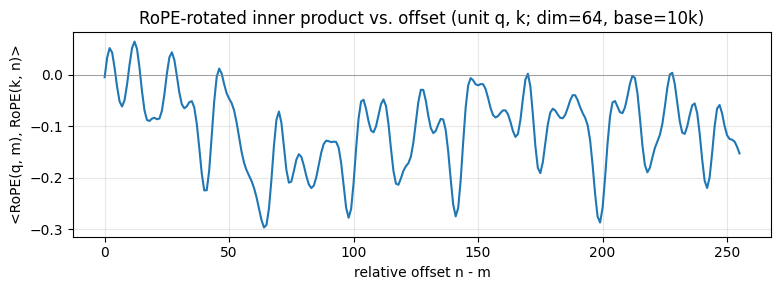

In [6]:
q_unit = torch.randn(dim); q_unit /= q_unit.norm()
k_unit = torch.randn(dim); k_unit /= k_unit.norm()

offsets = torch.arange(0, T)
scores = []
m = 0  # fix the query position
for off in offsets:
    n = m + off.item()
    qm = apply_rotary_emb(q_unit.view(1, 1, dim), freqs_cis[m:m+1]).view(dim)
    kn = apply_rotary_emb(k_unit.view(1, 1, dim), freqs_cis[n:n+1]).view(dim)
    scores.append((qm @ kn).item())

plt.figure(figsize=(8, 3))
plt.plot(offsets.numpy(), scores)
plt.axhline(0, color="gray", linewidth=0.5)
plt.xlabel("relative offset n - m")
plt.ylabel("<RoPE(q, m), RoPE(k, n)>")
plt.title("RoPE-rotated inner product vs. offset (unit q, k; dim=64, base=10k)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Two things to notice:

1. The function is **not** monotone decay (as a learned bias might give). It oscillates because the rotation goes around the circle. This is fine — attention learns to find the *peaks*, not to assume monotonicity.
2. The high-frequency wiggle is the fast pairs; the slow envelope is the slow pairs. The slowest pair's wavelength sets how far apart two positions can be before they start aliasing.

## 4. Long-context extension: PI vs NTK vs YaRN

Suppose you trained at 2k context and want to deploy at 8k (a 4× extension). Three schemes — visualize what each does to the per-pair frequencies.

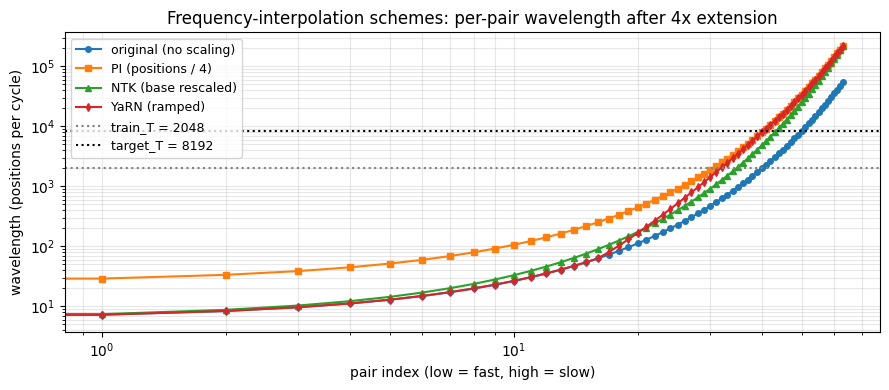

In [7]:
dim = 128
train_T = 2048
target_T = 8192
base = 10_000.0

# Per-pair indices and the original frequencies.
k_idx = torch.arange(0, dim, 2, dtype=torch.float32)
theta_original = 1.0 / (base ** (k_idx / dim))
wavelengths_orig = 2 * math.pi / theta_original

# What each scheme does to those frequencies, expressed as effective wavelength.
s = target_T / train_T

# PI: positions divided by s -> effective theta divided by s -> wavelengths * s
wl_pi = wavelengths_orig * s

# NTK: base scaled
base_ntk = base * s ** (dim / (dim - 2))
theta_ntk = 1.0 / (base_ntk ** (k_idx / dim))
wl_ntk = 2 * math.pi / theta_ntk

# YaRN: ramp between PI (slow pairs) and unchanged (fast pairs)
cycles_in_train = train_T / wavelengths_orig
beta_fast, beta_slow = 32.0, 1.0
ramp = ((cycles_in_train - beta_slow) / (beta_fast - beta_slow)).clamp(0.0, 1.0)
theta_yarn = theta_original * (ramp + (1 - ramp) / s)
wl_yarn = 2 * math.pi / theta_yarn

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(k_idx.numpy() / 2, wavelengths_orig.numpy(), "o-", label="original (no scaling)", markersize=4)
ax.loglog(k_idx.numpy() / 2, wl_pi.numpy(),         "s-", label=f"PI (positions / {s:.0f})", markersize=4)
ax.loglog(k_idx.numpy() / 2, wl_ntk.numpy(),        "^-", label="NTK (base rescaled)", markersize=4)
ax.loglog(k_idx.numpy() / 2, wl_yarn.numpy(),       "d-", label="YaRN (ramped)", markersize=4)
ax.axhline(train_T,  color="gray", linestyle=":", label=f"train_T = {train_T}")
ax.axhline(target_T, color="black", linestyle=":", label=f"target_T = {target_T}")
ax.set_xlabel("pair index (low = fast, high = slow)")
ax.set_ylabel("wavelength (positions per cycle)")
ax.set_title("Frequency-interpolation schemes: per-pair wavelength after 4x extension")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

Three things to read off the plot:

- **Original** (blue): the slowest pairs have wavelengths between `train_T` and `target_T`. Those are the ones that haven't completed a cycle during training, so the model has never seen the angles past position 2048. Bad at inference time at 8k.
- **PI** (orange): pushes *every* wavelength up by 4×. Fixes the slow end at the cost of the fast end — adjacent positions are now closer in angle space, so the model loses resolution. Recovers with fine-tuning.
- **NTK** (green): mostly stretches the slow end; the fast end barely moves. Better zero-shot, but the rescaling is a heuristic.
- **YaRN** (red): explicitly ramps between the regimes — high-frequency pairs (left side of the plot) stay close to the original curve, low-frequency pairs (right side) get the PI treatment. The transition band in the middle is the ramp.

Production long-context fine-tunes use YaRN with a few thousand steps of training; the temperature correction (Section 5.6 of the README) sharpens the softmax to compensate for the wider attention spread.

## 5. The full block — attention + RMSNorm + SwiGLU

Compose a `TransformerBlock` with each of the three Module-04 attention variants. All three produce `(B, T, d_model)` outputs and the block is fully pluggable.

In [8]:
B, T, d_model = 2, 64, 256
n_heads = 8
d_head = d_model // n_heads
x = torch.randn(B, T, d_model)

freqs_cis = precompute_freqs_cis(d_head, T)
freqs_cis_mla = precompute_freqs_cis(16, T)  # MLA uses d_rope=16

configs = [
    ("MHA",    MultiHeadAttention(d_model=d_model, n_heads=n_heads),                              freqs_cis),
    ("GQA(2)", GroupedQueryAttention(d_model=d_model, n_heads=n_heads, n_kv_heads=2),             freqs_cis),
    ("MLA",    MultiHeadLatentAttention(
                  d_model=d_model, n_heads=n_heads, d_head=d_head, d_rope=16, d_kv_latent=64),    freqs_cis_mla),
]

for name, attn, fc in configs:
    block = TransformerBlock(d_model=d_model, attention=attn)
    out = block(x, fc)
    n_attn = sum(p.numel() for p in attn.parameters())
    n_total = sum(p.numel() for p in block.parameters())
    n_ffn = sum(p.numel() for p in block.ffn.parameters())
    print(f"{name:7s}  out shape: {tuple(out.shape)}  "
          f"attn params: {n_attn/1e3:>7.1f}k  ffn params: {n_ffn/1e3:>7.1f}k  total: {n_total/1e3:>7.1f}k")

MHA      out shape: (2, 64, 256)  attn params:   262.1k  ffn params:   540.7k  total:   803.3k
GQA(2)   out shape: (2, 64, 256)  attn params:   163.8k  ffn params:   540.7k  total:   705.0k
MLA      out shape: (2, 64, 256)  attn params:   217.1k  ffn params:   540.7k  total:   758.3k


The FFN dominates at this size (and at every size). At $d=256$, $d_{\text{ffn}}$ rounds up to 704 from the 8/3 rule, so the SwiGLU carries $3 \cdot 256 \cdot 704 \approx 540\text{k}$ params. The attention path is much smaller because $d_{\text{model}}$ is small.

At realistic scales ($d_{\text{model}}=4096$+), attention and FFN each carry about half the layer's params for MHA; the FFN dominates more for GQA/MLA because their KV-side is compressed.

Verify the pre-norm wiring by checking that the block's output isn't normalized (only the input to each sub-layer is):

In [9]:
# Build one block and stack 4 of them. Track the RMS of the residual stream
# at each depth — pre-norm should let it grow gradually.
block_list = nn.ModuleList([
    TransformerBlock(d_model=d_model, attention=MultiHeadAttention(d_model, n_heads))
    for _ in range(4)
])

h = torch.randn(B, T, d_model)
rms_per_depth = [h.pow(2).mean(-1).sqrt().mean().item()]
for blk in block_list:
    h = blk(h, freqs_cis)
    rms_per_depth.append(h.pow(2).mean(-1).sqrt().mean().item())

for depth, r in enumerate(rms_per_depth):
    print(f"  depth {depth}:  residual-stream RMS = {r:.3f}")

  depth 0:  residual-stream RMS = 1.002
  depth 1:  residual-stream RMS = 1.012
  depth 2:  residual-stream RMS = 1.023
  depth 3:  residual-stream RMS = 1.033
  depth 4:  residual-stream RMS = 1.044


The residual stream RMS drifts modestly with depth (each block writes additively into the stream). At an untrained model with random weights the drift is unconstrained; with trained weights and the final RMSNorm at the model output, this stays controlled.

If you replaced pre-norm with post-norm here you'd see the RMS get clamped to ~1 after every block — which is what makes gradient flow brittle at depth. We don't show that experiment because nothing in this course uses post-norm.

## Recap

You now have:

- `RMSNorm` and `SwiGLU` implementations matching frontier-model recipes.
- A canonical RoPE with three scaling modes (PI, NTK, YaRN) for long-context extension.
- A `TransformerBlock` that accepts any Module-04 attention variant and is the building block for Module 07's full model.
- A numerical verification that RoPE inner products are relative-position-only.
- A visual intuition for how YaRN differs from PI and NTK.

**Next:** [Module 06 — Mixture of Experts](../06-mixture-of-experts/). The FFN you just built gets replaced by a router and a bank of expert FFNs; the new design constraint is keeping the routing balanced without hurting quality.